# K-means clustering

Michael Hunter

As usual, we start by getting some filepaths for the data. 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lab-15-k-means-clustering-d-4-2025/sample_submission.csv
/kaggle/input/lab-15-k-means-clustering-d-4-2025/data.csv


I import the data and take a look at it. Did we ever learn what this data was for? Maybe I missed that. 

In [2]:
import matplotlib.pyplot as plt

data_import = pd.read_csv("/kaggle/input/lab-15-k-means-clustering-d-4-2025/data.csv")
data_import.head()

,ID,RRmean,PTdis,STdis,RRTot,SDRR,hbpermin,PQdis,PQslope,QRdis,QRSseg,PQseg,Pseg,NN50,STseg,STslope,Tseg
0,0,358.185185,95.000002,36.375684,28,118.947245,60.179104,24.164337,-0.039751,16.971024,0.095734,0.068552,0.029563,11,0.101091,0.017092,0.108631
1,1,84.134454,20.786934,13.809141,120,3.059424,91.428571,7.078599,-0.193178,0.050422,0.021151,0.063310,0.050924,1,0.100705,0.063261,0.089558
2,2,315.258064,89.258170,21.690140,32,11.503065,68.571429,29.003153,-0.013569,22.501573,0.101389,0.084500,0.064722,4,0.068889,0.034507,0.094667
3,3,197.693878,38.413132,25.029068,50,1.798004,75.000000,13.531768,-0.136163,0.000000,0.000000,0.053095,0.064714,0,0.100000,0.048226,0.100190
4,4,312.838710,105.806455,35.747960,32,11.273997,68.503469,38.327021,-0.015234,16.125269,0.088108,0.106771,0.043837,2,0.099306,0.018280,0.095399


Take a look at the shape and info of the dataframe. Apparently we have 900 items here. 

In [3]:
print(data_import.shape)

(900, 17)


In [4]:
print(data_import.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        900 non-null    int64  
 1   RRmean    900 non-null    float64
 2   PTdis     900 non-null    float64
 3   STdis     900 non-null    float64
 4   RRTot     900 non-null    int64  
 5   SDRR      900 non-null    float64
 6   hbpermin  900 non-null    float64
 7   PQdis     900 non-null    float64
 8   PQslope   900 non-null    float64
 9   QRdis     900 non-null    float64
 10  QRSseg    900 non-null    float64
 11  PQseg     900 non-null    float64
 12  Pseg      900 non-null    float64
 13  NN50      900 non-null    int64  
 14  STseg     900 non-null    float64
 15  STslope   900 non-null    float64
 16  Tseg      900 non-null    float64
dtypes: float64(14), int64(3)
memory usage: 119.7 KB
None


The ID column is probably not wanted, so I'll get rid of it. 

In [5]:
data = data_import.drop("ID", axis = 1)
data.head()

,RRmean,PTdis,STdis,RRTot,SDRR,hbpermin,PQdis,PQslope,QRdis,QRSseg,PQseg,Pseg,NN50,STseg,STslope,Tseg
0,358.185185,95.000002,36.375684,28,118.947245,60.179104,24.164337,-0.039751,16.971024,0.095734,0.068552,0.029563,11,0.101091,0.017092,0.108631
1,84.134454,20.786934,13.809141,120,3.059424,91.428571,7.078599,-0.193178,0.050422,0.021151,0.063310,0.050924,1,0.100705,0.063261,0.089558
2,315.258064,89.258170,21.690140,32,11.503065,68.571429,29.003153,-0.013569,22.501573,0.101389,0.084500,0.064722,4,0.068889,0.034507,0.094667
3,197.693878,38.413132,25.029068,50,1.798004,75.000000,13.531768,-0.136163,0.000000,0.000000,0.053095,0.064714,0,0.100000,0.048226,0.100190
4,312.838710,105.806455,35.747960,32,11.273997,68.503469,38.327021,-0.015234,16.125269,0.088108,0.106771,0.043837,2,0.099306,0.018280,0.095399


# Scaling the data

I'll use a standard scaler so everything is close to zero and roughly the same range. 

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_sc = scaler.fit_transform(data)
# This returns a numpy.ndarray for some damn reason!

# Take a look at the 0th row of data
data_sc[0]

array([ 1.57548588,  1.44027469,  1.28760056, -1.19700843,  1.18498181,
       -1.23106344,  0.48327577,  0.65435597,  1.61822272,  1.25719776,
       -0.47214248, -3.25575843,  0.91774483,  0.65589895, -0.93820272,
        0.34986274])

# Experimentation

I'll experiment with different numbers of clusters. I'll also use several different seeds and see how that affects the results. I'll create a dictionary of all the results because pandas dataframes don't like to implement the append() function very well. 

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# cluster size of 1 doesn't make much sense, and I doubt using like 20 clusters is useful. 
n_clusters = range(2, 11)
rand_seeds = range(11)

results_dict = {"seed":       [],
                "clusters":   [],
                "inertia":    [],
                "silhouette": []}

for sd in rand_seeds:
    for clusters in n_clusters:
        # n_init = 'auto' prevents a bunch of warnings from popping up.
        kmeans = KMeans(n_clusters = clusters, n_init='auto', random_state = sd)
        labels = kmeans.fit_predict(data_sc)
        
        results_dict["seed"].append(sd)
        results_dict["clusters"].append(clusters)
        results_dict["inertia"].append(kmeans.inertia_)
        results_dict["silhouette"].append(silhouette_score(data_sc, labels))


results = pd.DataFrame(results_dict)
print(results.head())

   seed  clusters       inertia  silhouette
0     0         2  10270.418603    0.292798
1     0         3   8016.858205    0.297941
2     0         4   6854.263395    0.291450
3     0         5   6326.212052    0.275417
4     0         6   5660.499790    0.286321


Then, I'll graph the results of the above operations to see what looks like the best number of clusters. It took me a while to figure out that I should add each set of lines in one at a time, and `results.loc[results['seed'] == rand]` took me a while to figure out. (this limits the results dataframe to just the ones with the correct seed, so each line is a different color). I probably need more practice with indexing dataframes. 

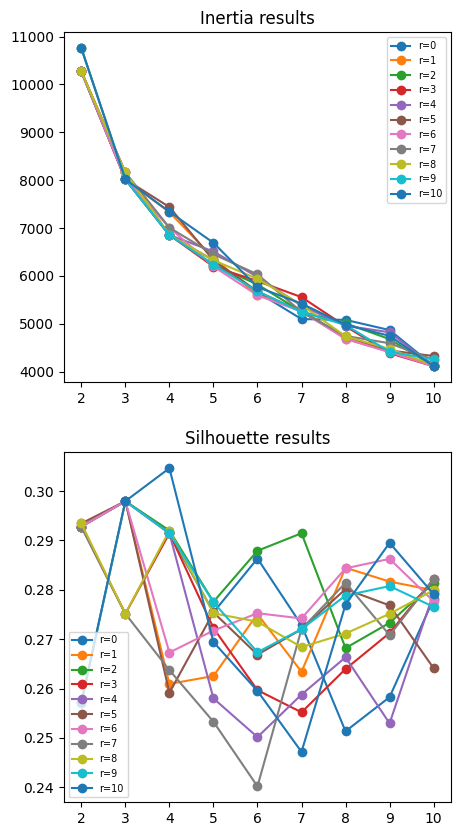

In [8]:
fig, axs = plt.subplots(2)
fig.set_size_inches(5, 10)

for rand in rand_seeds:
    axs[0].plot("clusters", "inertia", "o-", 
                data = results.loc[results['seed'] == rand],
                label = f"r={rand}")
    axs[1].plot("clusters", "silhouette", "o-", 
                data = results.loc[results['seed'] == rand],
                label = f"r={rand}")

axs[0].legend(fontsize = "x-small")
axs[0].set_title("Inertia results")

axs[1].legend(fontsize = "x-small")
axs[1].set_title("Silhouette results")

fig.show()

The graphs are pretty confusing, but it looks like the 'elbow' in the Inertia graph is at 3, and the max value of Silhouette in the second graph might be 3 or 4 for several of the graphs, although that really jumps around a lot, depending on the seed. So I might use 3 clusters, and try different random seeds. 

# Some good seed

I decided to do a 3-d graph of the 3 principle components for the original data. This took a little bit to figure out how to do, but it worked out really nicely, I think. I wish you could grab the graph and rotate it around, but I didn't figure out how to do that. 

In [9]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from time import time

# 3 clusters seems to work. Let's see if we can find a good random seed
clusters = 3
seed_range = range(0, 100_000_000, 1_102_713) # just trying some weird numbers for seeds
max_silhouette = -1
max_seed = -1

start = time()
for seed in seed_range:
    kmeans = KMeans(n_clusters = clusters, n_init='auto', random_state = seed)
    labels = kmeans.fit_predict(data_sc)

    sil = silhouette_score(data_sc, labels)

    if sil > max_silhouette:
        max_silhouette = sil
        max_seed = seed
end = time()

print(f"max_sil = {max_silhouette}")
print(f"max_seed = {max_seed}")
print(f"time = {end - start}")

max_sil = 0.2979412133293922
max_seed = 0
time = 2.013854503631592


It seems as though the seed is not affecting the `max_sil` if the number of clusters is 3. If I change that to 4, I do get different results for different seeds, however. But with 4 clusters, the final result that I submit is really bad. So I will try and visualize what's going on a bit. 

# 3-d Graph of the data

I'll make a 3-d scatterplot of the data. I'll need to reduce the number of components down to 3 for this to work. 

explained variance ratio: [0.38707194 0.24100107 0.0998863 ]
shape: (900, 3)
inertia: 8016.858205288324
silhouette: 0.2979412133293922


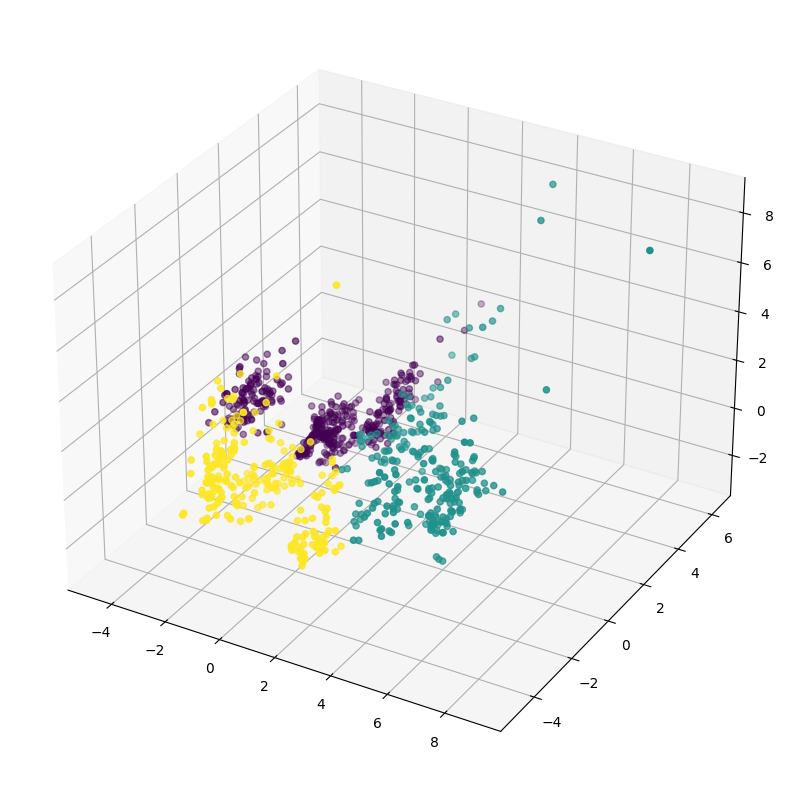

In [10]:
# Let's make a 3-d scatter plot of one of these! For fun!

# use the best results from above. 
kmeans = KMeans(n_clusters = clusters, n_init='auto', random_state = max_seed)
labels = kmeans.fit_predict(data_sc)

# reduce the components to 3
pca = PCA(n_components = 3)
data_pca = pca.fit_transform(data_sc)

print(f"explained variance ratio: {pca.explained_variance_ratio_}")
print(f"shape: {data_pca.shape}")
print(f"inertia: {kmeans.inertia_}")
print(f"silhouette: {silhouette_score(data_sc, labels)}")

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# Plot x, y, z = the three columns of the data_pca. assign labels for color
ax.scatter(data_pca[:,0], data_pca[:,1], data_pca[:,2], c = labels)

fig.set_size_inches(10, 10)
fig.show()

Somehow that doesn't look right in the upper left of the graph. With 3 components what seem to be two separate regions seem to fall into the same region most of the time. If you change the number of components to 4 we can get a more visually compelling graph, but I don't know if it is actually any better. So I'll just submit this. 

In [11]:
submission = pd.DataFrame({
    'ID': data_import['ID'],
    'Category': labels
})

submission.to_csv("submission.csv", index=False)
print(submission.head())

   ID  Category
0   0         1
1   1         0
2   2         1
3   3         0
4   4         1
